In [3]:
# 데이터 처리를 위한 pandas를 불러옵니다.
import pandas as pd

# 그래프를 그리기 위한 matplotlib와 seaborn을 불러옵니다.
import matplotlib.pyplot as plt
import seaborn as sns

# 폴더 생성을 위해 os를 불러옵니다.
import os

# 윈도우 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 결과 저장 폴더 생성
os.makedirs("../images", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)


In [4]:
# 공통 전처리 데이터를 불러옵니다.
df = pd.read_csv(
    "../data/processed/violation_2017_2023.csv",
    encoding="utf-8-sig",
    parse_dates=["위반일자"]
)

print("데이터 크기:", df.shape)
print("분석 기간:", df["위반일자"].min(), "~", df["위반일자"].max())
print("컬럼:", df.columns.tolist())

display(df.head())

데이터 크기: (681828, 10)
분석 기간: 2017-01-01 00:00:00 ~ 2023-12-31 00:00:00
컬럼: ['구분', '위반일자', '위반시간', '위반장소', '과태료부과일자', '데이터기준일자', '시간', '연도', '월', '요일']


,구분,위반일자,위반시간,위반장소,과태료부과일자,데이터기준일자,시간,연도,월,요일
0,불법주정차,2017-01-01,11:08,태전1동 관음타운상가,2017-01-02,2023-07-04,11,2017,1,일요일
1,불법주정차,2017-01-01,12:42,대현동 동대구시장,2017-01-02,2023-07-04,12,2017,1,일요일
2,불법주정차,2017-01-01,14:24,침산동 건영하이츠(본죽),2017-01-02,2023-07-04,14,2017,1,일요일
3,불법주정차,2017-01-01,14:59,침산동 건영하이츠(본죽),2017-01-02,2023-07-04,14,2017,1,일요일
4,불법주정차,2017-01-01,15:33,서변동 행운보석,2017-01-02,2023-07-04,15,2017,1,일요일


In [5]:
# 위반장소를 문자열로 바꾸고 앞뒤 공백을 제거합니다.
df["위반장소_정리"] = df["위반장소"].astype(str).str.strip()

# 연속된 공백을 한 칸으로 통일합니다.
df["위반장소_정리"] = df["위반장소_정리"].str.replace(r"\s+", " ", regex=True)

# 빈 장소명 확인
empty_place = df["위반장소_정리"].isin(["", "nan", "None"])
print("장소명이 비어 있는 행 수:", empty_place.sum())

# 장소명이 정상인 데이터만 사용
place_df = df[~empty_place].copy()

print("분석에 사용하는 데이터 건수:", len(place_df))
print("서로 다른 장소명 수:", place_df["위반장소_정리"].nunique())

장소명이 비어 있는 행 수: 0
분석에 사용하는 데이터 건수: 681828
서로 다른 장소명 수: 30448


In [6]:
# 장소별 단속 건수를 계산하고 상위 10개 장소를 선택합니다.
top10_places = place_df["위반장소_정리"].value_counts().head(10)

print(top10_places)

위반장소_정리
동아아울렛 뒤편         17189
동천동 회전교차로        10194
산격3동치안센터          9074
대학로79 파리바게트 부     6938
침산 화인탑펠리스         6652
사수동 센스마트          5943
대구일중학교 정문 앞       5881
노원LH아파트 후문        5773
운암지               4810
동변공원 사거리          4549
Name: count, dtype: int64


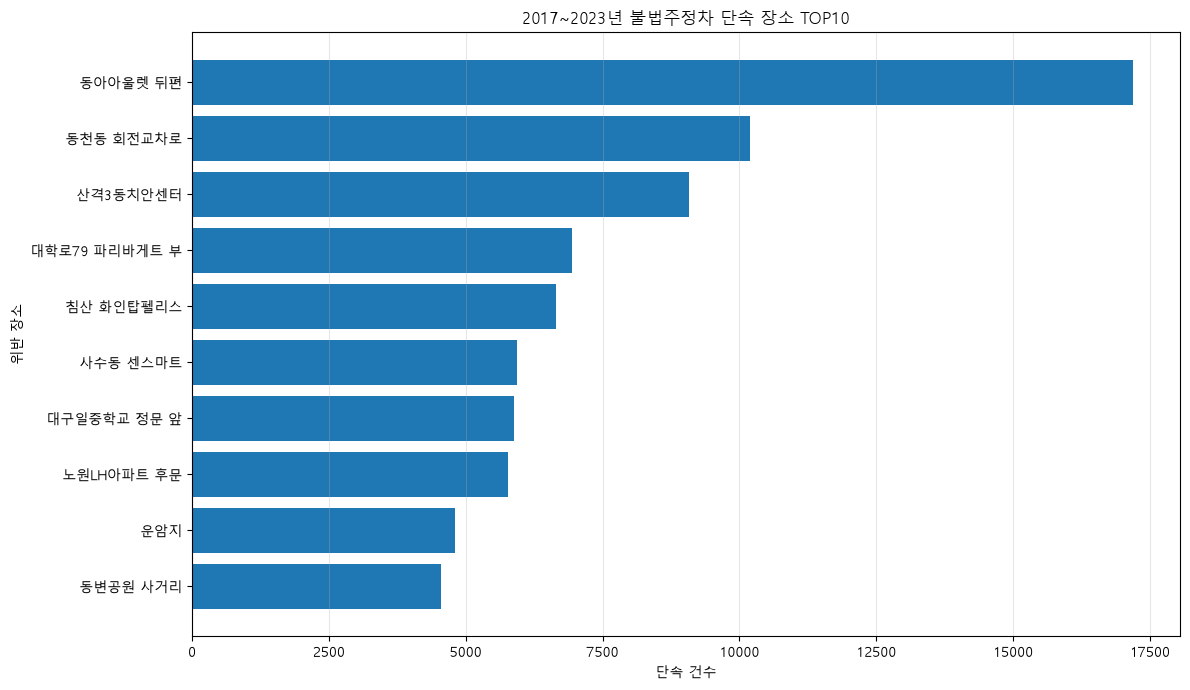

In [7]:
# 장소명이 길기 때문에 가로 막대그래프로 나타냅니다.
plt.figure(figsize=(12, 7))
plt.barh(top10_places.index, top10_places.values)
plt.gca().invert_yaxis()

plt.title("2017~2023년 불법주정차 단속 장소 TOP10")
plt.xlabel("단속 건수")
plt.ylabel("위반 장소")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig("../images/location_top10_places.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# TOP10 장소 이름을 리스트로 저장합니다.
top10_list = top10_places.index.tolist()

# TOP10 장소 데이터만 선택합니다.
top10_df = place_df[place_df["위반장소_정리"].isin(top10_list)].copy()

# 장소와 시간을 기준으로 단속 건수를 교차 집계합니다.
place_hour = pd.crosstab(
    top10_df["위반장소_정리"],
    top10_df["시간"]
)

# 0~23시가 모두 보이도록 열을 맞춥니다.
place_hour = place_hour.reindex(columns=range(24), fill_value=0)

# TOP10 순위를 유지하도록 행 순서를 맞춥니다.
place_hour = place_hour.reindex(top10_list)

display(place_hour)

시간,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
위반장소_정리,,,,,,,,,,,,,,,,,,,,,
동아아울렛 뒤편,0,0,0,0,0,0,0,307,346,774,...,3575,2739,2551,1375,1564,1405,0,0,0,0
동천동 회전교차로,0,0,0,0,0,0,0,508,109,149,...,1404,1605,1597,584,1012,1976,0,0,0,0
산격3동치안센터,0,0,0,0,0,0,0,0,0,0,...,923,856,835,888,1139,1244,19,0,0,0
대학로79 파리바게트 부,0,0,0,0,0,0,0,0,0,0,...,789,740,695,520,625,804,13,0,0,0
침산 화인탑펠리스,0,0,0,0,0,0,0,468,119,191,...,1717,1207,1084,388,399,22,0,0,0,0
사수동 센스마트,0,0,0,0,0,0,0,568,211,351,...,1163,815,750,379,349,314,0,0,0,0
대구일중학교 정문 앞,0,0,0,0,0,0,0,704,123,265,...,1143,980,813,176,215,247,0,0,0,0
노원LH아파트 후문,0,0,0,0,0,0,0,314,91,144,...,1117,1097,1088,361,321,336,0,0,0,0
운암지,0,0,0,0,0,0,0,313,105,123,...,1368,920,654,159,180,46,0,0,0,0


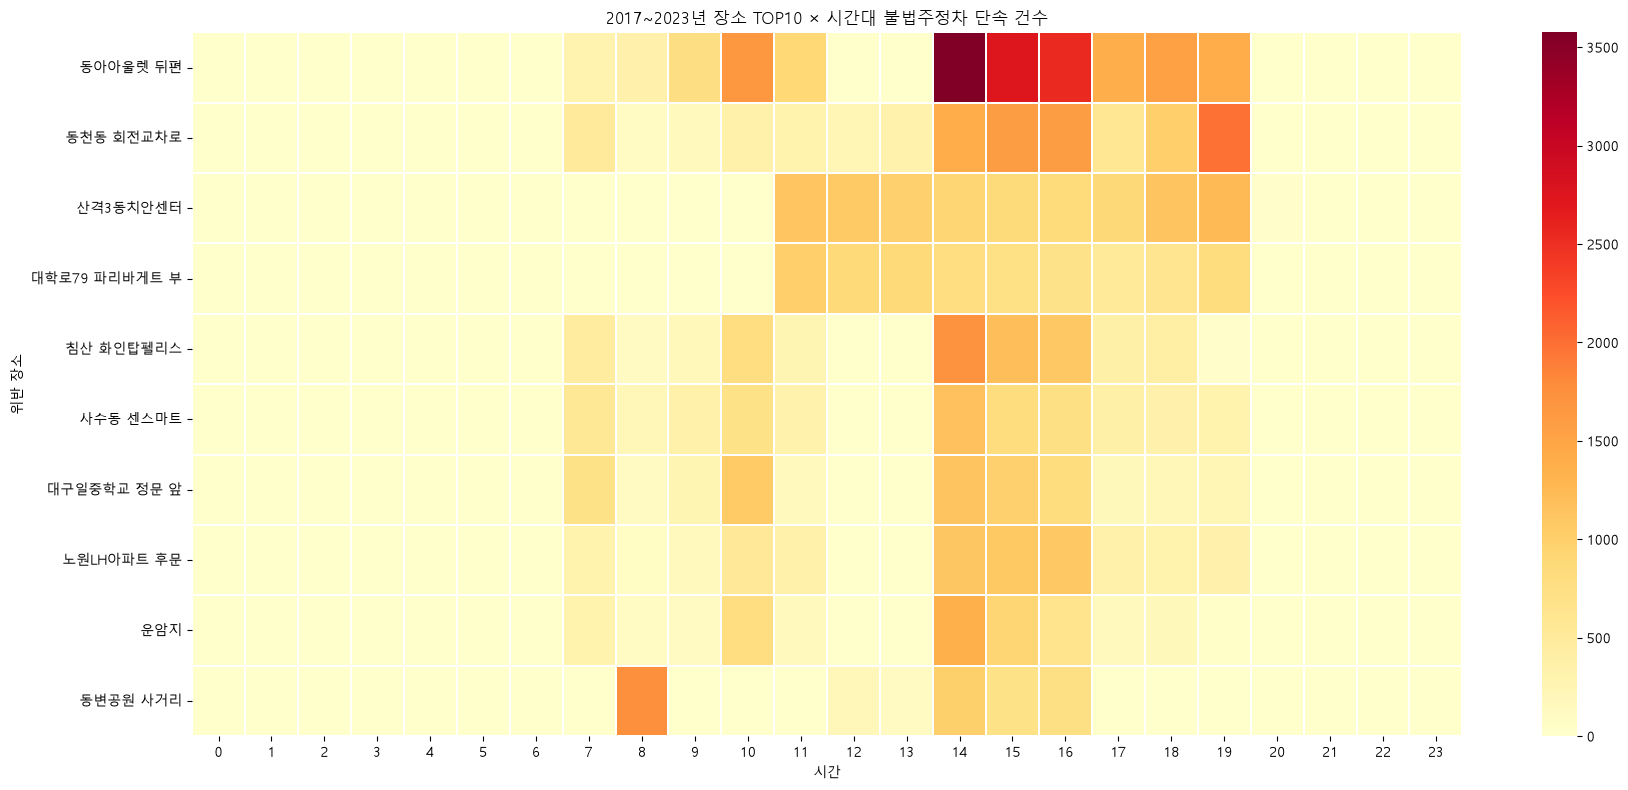

In [9]:
# 장소 × 시간 단속 건수를 히트맵으로 나타냅니다.
plt.figure(figsize=(18, 8))
sns.heatmap(place_hour, cmap="YlOrRd", linewidths=0.2)

plt.title("2017~2023년 장소 TOP10 × 시간대 불법주정차 단속 건수")
plt.xlabel("시간")
plt.ylabel("위반 장소")
plt.tight_layout()

plt.savefig("../images/location_top10_hour_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# 요일 순서를 지정합니다.
weekday_order = [
    "월요일", "화요일", "수요일", "목요일",
    "금요일", "토요일", "일요일"
]

# TOP10 장소별 요일 단속 건수를 교차 집계합니다.
place_weekday = pd.crosstab(
    top10_df["위반장소_정리"],
    top10_df["요일"]
).reindex(columns=weekday_order, fill_value=0)

# TOP10 순위를 유지합니다.
place_weekday = place_weekday.reindex(top10_list)

# 장소별 요약 정보를 만듭니다.
summary_rows = []

for place in top10_list:
    summary_rows.append({
        "위반장소": place,
        "총단속건수": int(top10_places.loc[place]),
        "집중시간": int(place_hour.loc[place].idxmax()),
        "집중시간건수": int(place_hour.loc[place].max()),
        "집중요일": place_weekday.loc[place].idxmax(),
        "집중요일건수": int(place_weekday.loc[place].max())
    })

location_summary = pd.DataFrame(summary_rows)

display(location_summary)


,위반장소,총단속건수,집중시간,집중시간건수,집중요일,집중요일건수
0,동아아울렛 뒤편,17189,14,3575,월요일,2723
1,동천동 회전교차로,10194,19,1976,일요일,2306
2,산격3동치안센터,9074,19,1244,일요일,2071
3,대학로79 파리바게트 부,6938,11,1007,일요일,1791
4,침산 화인탑펠리스,6652,14,1717,일요일,1362
5,사수동 센스마트,5943,14,1163,금요일,932
6,대구일중학교 정문 앞,5881,14,1143,일요일,1403
7,노원LH아파트 후문,5773,14,1117,금요일,908
8,운암지,4810,14,1368,일요일,1412
9,동변공원 사거리,4549,8,1749,금요일,968


In [12]:
# 연도와 장소를 기준으로 단속 건수를 교차 집계합니다.
place_year = (
    top10_df.groupby(["위반장소_정리", "연도"])
    .size()
    .unstack(fill_value=0)
    .reindex(top10_list)
)

display(place_year)


연도,2017,2018,2019,2020,2021,2022,2023
위반장소_정리,,,,,,,
동아아울렛 뒤편,2991,4037,3112,1772,2421,1821,1035
동천동 회전교차로,2665,1940,2157,1550,630,798,454
산격3동치안센터,3260,2075,2218,1521,0,0,0
대학로79 파리바게트 부,1871,1722,934,1291,1062,58,0
침산 화인탑펠리스,0,0,1765,1469,1187,1185,1046
사수동 센스마트,0,0,3485,694,583,650,531
대구일중학교 정문 앞,0,0,0,1739,1998,1223,921
노원LH아파트 후문,0,0,1736,1395,1213,1139,290
운암지,0,0,644,1617,1044,826,679


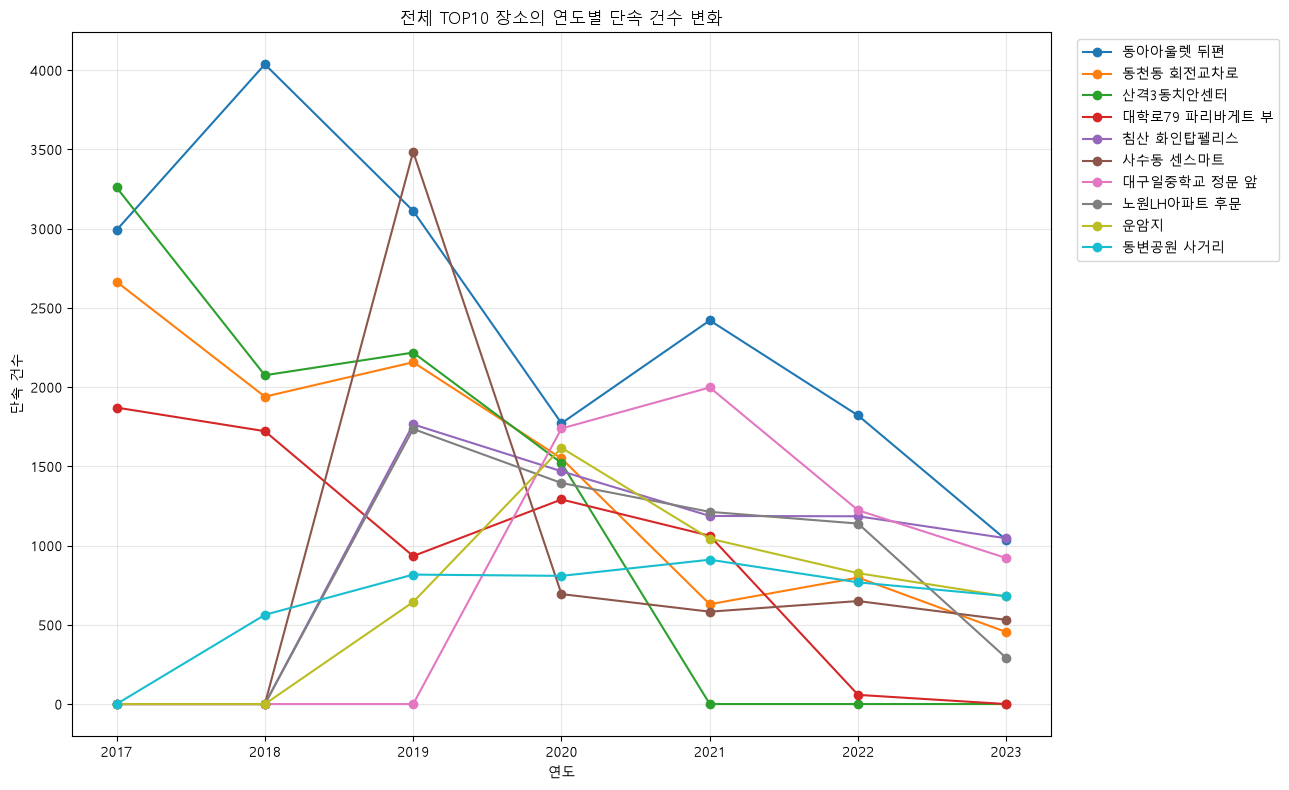

In [13]:
# TOP10 장소의 연도별 변화를 선그래프로 나타냅니다.
plt.figure(figsize=(13, 8))

for place in top10_list:
    plt.plot(
        place_year.columns,
        place_year.loc[place],
        marker="o",
        label=place
    )

plt.title("전체 TOP10 장소의 연도별 단속 건수 변화")
plt.xlabel("연도")
plt.ylabel("단속 건수")
plt.xticks(place_year.columns)
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig("../images/location_top10_year_trend.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# 장소 TOP10 요약
summary_path = "../data/processed/location_top10_summary.csv"
location_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

# 장소 × 시간 교차표
hour_path = "../data/processed/location_top10_hour.csv"
place_hour.to_csv(hour_path, encoding="utf-8-sig")

# 장소 × 연도 교차표
year_path = "../data/processed/location_top10_year.csv"
place_year.to_csv(year_path, encoding="utf-8-sig")

print("저장 완료:", summary_path)
print("저장 완료:", hour_path)
print("저장 완료:", year_path)


저장 완료: ../data/processed/location_top10_summary.csv
저장 완료: ../data/processed/location_top10_hour.csv
저장 완료: ../data/processed/location_top10_year.csv


In [15]:
# 가장 많은 장소의 핵심 결과를 출력합니다.
top_place = location_summary.iloc[0]

print("단속 건수가 가장 많은 장소:", top_place["위반장소"])
print("총 단속 건수:", f"{top_place['총단속건수']:,}", "건")
print("집중 시간:", int(top_place["집중시간"]), "시")
print("집중 요일:", top_place["집중요일"])

print("\n※ 장소 분석 결과는 시간·민원·CCTV 분석과 함께 최종적으로 해석합니다.")


단속 건수가 가장 많은 장소: 동아아울렛 뒤편
총 단속 건수: 17,189 건
집중 시간: 14 시
집중 요일: 월요일

※ 장소 분석 결과는 시간·민원·CCTV 분석과 함께 최종적으로 해석합니다.
